
SENTINEL TECH 9.0 — COMPARATIVO PRINCIPAL
         Model     FinalEq   Total%  CAGR%  Vol%  Sharpe  Sortino  MaxDD%  Calmar  AvgExp%  TimeInMkt%  TurnoverAnn  CVaR5%
SENTINEL_TECH9   912817.81   812.82  11.19 11.15   1.007    1.556  -17.35   0.645     43.7        65.5         7.71  -1.812
 BUY_HOLD_TECH 12341142.00 12241.14  25.98 27.00   0.991    1.610  -60.05   0.433    100.0       100.0         0.00  -3.999
          ^NDX  1476093.59  1376.09  13.78 21.97   0.698    1.107  -53.71   0.257    100.0       100.0         0.00  -3.320
           QQQ  1706787.41  1606.79  14.58 21.54   0.740    1.176  -53.40   0.273    100.0       100.0         0.00  -3.253
           SPY   782591.46   682.59  10.37 18.99   0.615    0.954  -55.19   0.188    100.0       100.0         0.00  -2.933

ROBUSTEZ (Purged Walk-Forward CV, 2 años test)
score=0.716 | avgSharpe=1.121 | stdSharpe=0.507 | worstDD=-16.59% | splits=11

STRESS EPISODES (burn-in=0)
   Episode  CAGR%  Sharpe  MaxDD%  Calmar  AvgExposure%  T

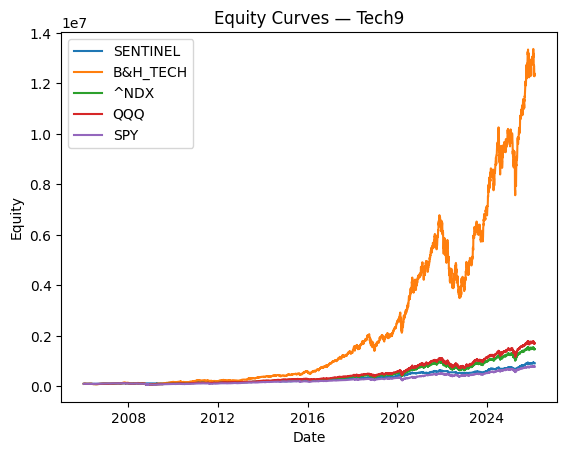

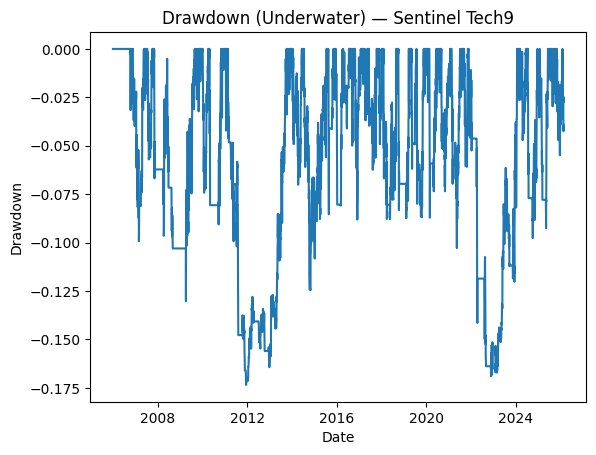

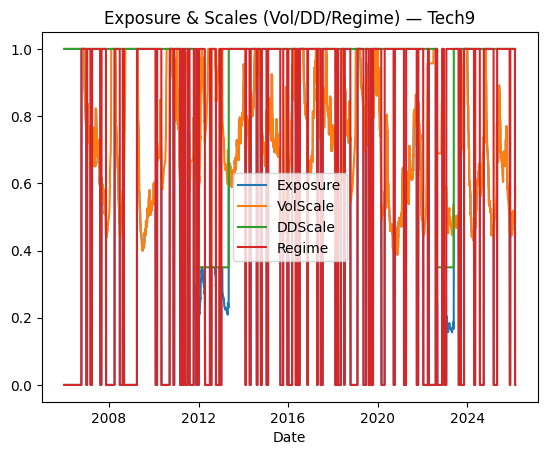

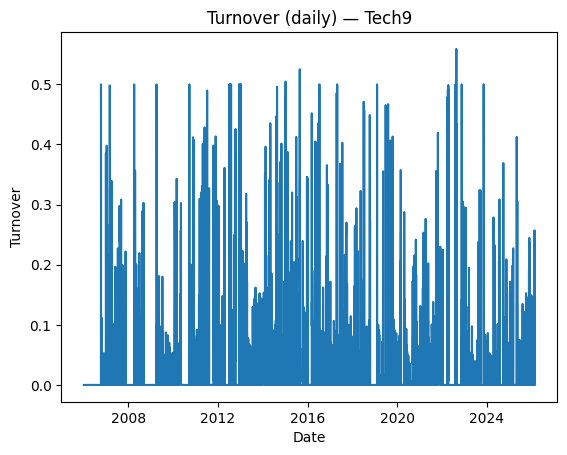

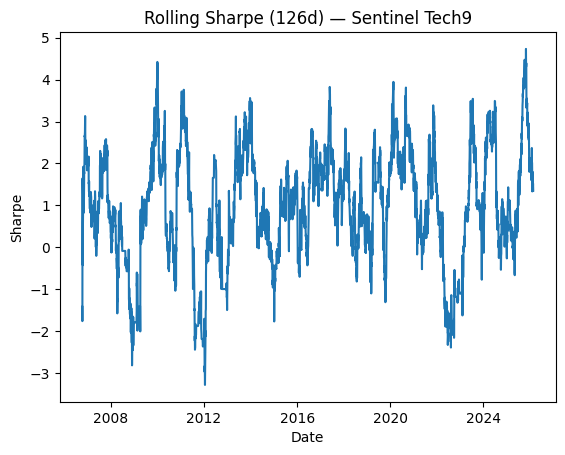

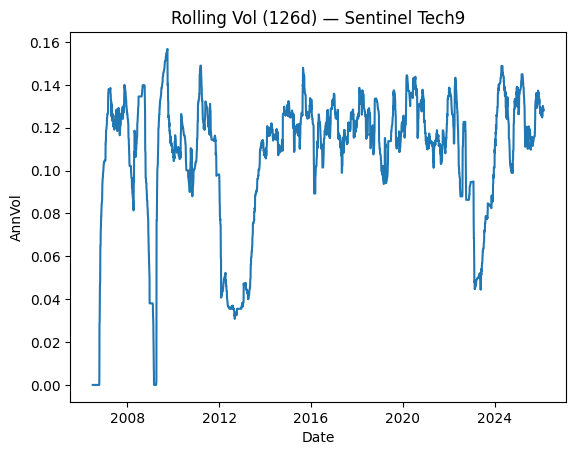

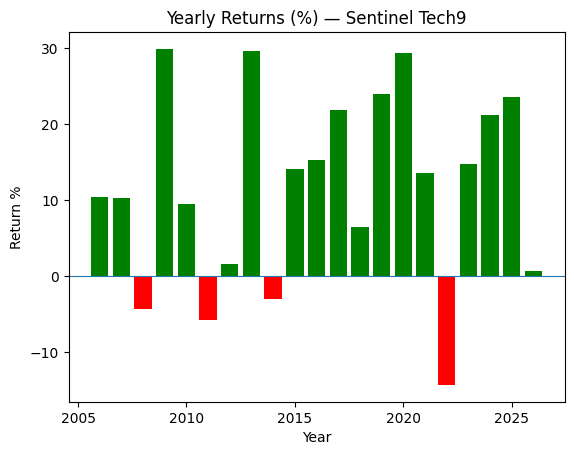

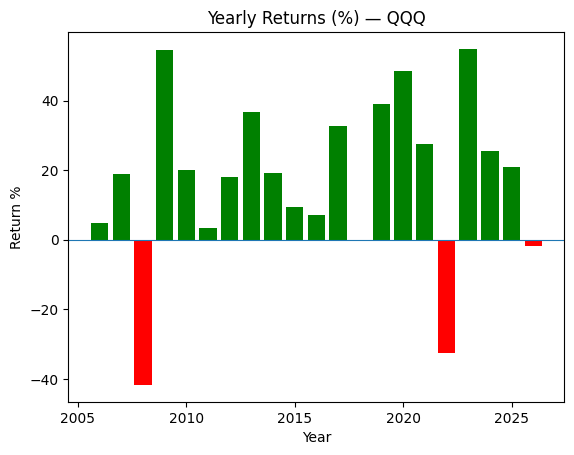


Monthly return table (%): Sentinel Tech9
Month     1     2     3     4     5     6     7     8     9     10    11    12
Year                                                                          
2006    0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  5.22  6.95 -1.90
2007   -2.33 -2.75  0.14  5.56  3.66  1.40  2.18 -2.36  4.50  6.31 -5.76  0.00
2008    0.00  0.00  0.00  1.89  2.77 -5.46  0.00 -2.77 -0.63  0.00  0.00  0.00
2009    0.00  0.00  0.00  3.76  1.26  0.76  3.02  1.94  3.72  0.17  6.12  5.96
2010   -7.04  0.42  6.26  1.55 -3.86  0.00  0.00  0.00  1.77  6.11  1.84  2.73
2011    7.53  2.26 -1.64 -1.82 -0.46  0.00 -1.17 -7.30  0.00  0.45 -2.58 -0.65
2012    1.44  1.61  1.83 -1.19  0.00  0.00 -1.26  1.39 -0.09 -1.79  0.00 -0.32
2013    3.17 -0.24 -0.19  1.21  3.23 -0.13  3.71  1.58  4.57  3.11  2.01  4.31
2014   -2.00 -0.08 -0.59 -3.34  5.21  3.15 -2.51  1.20 -1.39 -5.13  4.40 -1.47
2015   -0.82  4.33 -3.50  3.33  3.13 -2.37  6.22 -1.68  0.00  2.68  2.72 -0.33
2016   -5.

In [6]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import hashlib
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

# =========================
# CONFIG
# =========================

@dataclass
class CostsConfig:
    commission: float = 0.001      # costo por rotación (proxy institucional simple)
    slippage: float = 0.0002       # proxy adicional por rotación
    apply_slippage: bool = True


@dataclass
class Tech9Config:
    capital_initial: float = 100000.0
    start: str = "2006-01-01"
    end: str = "2026-02-20"
    trading_days: int = 252
    rf_annual: float = 0.0

    # Universo y benchmarks
    universe: Tuple[str, ...] = ('AAPL','MSFT','NVDA','GOOGL','AMZN','META','AVGO','ASML','TSM','ADBE','NFLX','AMD')
    index_ticker: str = "^NDX"   # régimen y benchmark conceptual (ojo: puede ser price index)
    tradable_proxy: str = "QQQ"  # benchmark tradable
    market_proxy: str = "SPY"    # mercado amplio

    # ---- Trend ensemble ----
    use_kama: bool = True
    kama_n: int = 30
    kama_fast: int = 2
    kama_slow: int = 60

    ema_spans: Tuple[int, ...] = (50, 100, 200)   # ensemble EMAs
    ensemble_threshold_on: float = 0.60           # histéresis: entrar si score >= 0.60
    ensemble_threshold_off: float = 0.40          # salir si score <= 0.40
    burn_in: int = 200                            # estabiliza EMAs/KAMA (global)

    # ---- Regime filter del índice ----
    regime_use: bool = True
    regime_kama_n: int = 40
    regime_fast: int = 2
    regime_slow: int = 80
    regime_threshold_on: float = 0.55            # histéresis en régimen
    regime_threshold_off: float = 0.45

    # ---- Risk overlay ----
    # Vol targeting (cash, sin apalancamiento)
    vol_target_on: bool = True
    vol_window: int = 63
    vol_target_ann: float = 0.12
    max_exposure: float = 1.0                    # sin leverage
    min_exposure: float = 0.10                   # evita “muerto” (10% mínimo cuando risk-on)

    # Trailing stop por activo
    trailing_on: bool = True
    trailing_stop_pct: float = 0.12              # 12% trailing
    reentry_allowed: bool = True                 # permite re-entrada si la señal vuelve a estar on

    # DD overlay portafolio (reduce exposición, no la mata)
    dd_overlay_on: bool = True
    dd_stop_level: float = 0.15                  # si DD <= -15% reduce fuerte
    dd_hard_level: float = 0.25                  # si DD <= -25% reduce aún más
    dd_recovery_level: float = 0.08              # si DD >= -8% vuelve a normal
    dd_scale_soft: float = 0.35                  # exposición multiplicador en dd_stop_level
    dd_scale_hard: float = 0.15                  # exposición multiplicador en dd_hard_level

    # ---- Validación ----
    cv_train_years: int = 8
    cv_test_years: int = 2
    purge_days: int = 10
    embargo_days: int = 5

    # Score robusto
    dd_cap_cv: float = -0.35
    lambda_dd: float = 2.0
    lambda_var: float = 0.8
    min_splits: int = 4

    # ---- Performance ----
    cache_dir: str = "data_cache"
    cache_max_age_days: int = 30  # refresco si quiere


STRESS_EPISODES = {
    "GFC_2008": ("2008-01-01", "2009-06-30"),
    "EURO_2011": ("2011-07-01", "2011-12-31"),
    "Q4_2018": ("2018-10-01", "2018-12-31"),
    "COVID_2020": ("2020-02-15", "2020-06-30"),
    "RATES_2022": ("2022-01-01", "2022-12-31"),
}

# =========================
# HELPERS
# =========================

def to_1d_series(x, name="x") -> pd.Series:
    if x is None:
        return pd.Series(dtype=float, name=name)
    if isinstance(x, pd.Series):
        return x.rename(name)
    if isinstance(x, pd.DataFrame):
        if x.shape[1] == 0:
            return pd.Series(dtype=float, name=name)
        return x.iloc[:, 0].rename(name)
    arr = np.asarray(x)
    if arr.ndim == 2 and arr.shape[1] == 1:
        arr = arr.reshape(-1)
    return pd.Series(arr, name=name)

def _hash_key(obj: dict) -> str:
    s = json.dumps(obj, sort_keys=True).encode("utf-8")
    return hashlib.md5(s).hexdigest()

def _ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def kama(price: np.ndarray, n: int = 10, fast: int = 2, slow: int = 30) -> np.ndarray:
    price = np.asarray(price, dtype=float)
    length = len(price)
    out = np.full(length, np.nan)
    if length == 0:
        return out
    out[0] = price[0]
    fast_sc = 2.0 / (fast + 1.0)
    slow_sc = 2.0 / (slow + 1.0)
    for i in range(1, length):
        if i < n:
            out[i] = price[i]
        else:
            change = abs(price[i] - price[i - n])
            volatility = np.sum(np.abs(np.diff(price[i - n + 1:i + 1])))
            er = 0.0 if volatility == 0 else change / volatility
            sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
            out[i] = out[i - 1] + sc * (price[i] - out[i - 1])
    return out

# =========================
# DATA (with cache)
# =========================

def download_close_cached(tickers: List[str], start: str, end: str, cache_dir: str) -> pd.DataFrame:
    """
    Descarga closes ajustados auto_adjust=True.
    Cachea a CSV para rapidez en runs repetidos.
    - NO usa bfill
    - ffill limitado (huecos cortos)
    """
    _ensure_dir(cache_dir)
    key = _hash_key({"tickers": tickers, "start": start, "end": end, "auto_adjust": True})
    path = os.path.join(cache_dir, f"prices_{key}.csv")

    if os.path.exists(path):
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        return df

    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, group_by="ticker", progress=False)

    idx = pd.bdate_range(start=start, end=end)
    df = pd.DataFrame(index=idx)

    for t in tickers:
        try:
            if isinstance(raw, pd.DataFrame) and "Close" in raw.columns:
                s = raw["Close"]
                if isinstance(s, pd.DataFrame):
                    s = s[t] if t in s.columns else None
            else:
                s = raw[t]["Close"]
            if s is None:
                continue
            s = pd.Series(s).dropna()
            if s.empty:
                continue
            s = s.reindex(idx).ffill(limit=5)
            df[t] = s
        except Exception:
            continue

    df = df.dropna(how="all")
    df.to_csv(path)
    return df

def download_benchmark_close_cached(ticker: str, start: str, end: str, cache_dir: str) -> pd.Series:
    _ensure_dir(cache_dir)
    key = _hash_key({"ticker": ticker, "start": start, "end": end, "auto_adjust": True})
    path = os.path.join(cache_dir, f"bench_{key}.csv")

    if os.path.exists(path):
        s = pd.read_csv(path, index_col=0, parse_dates=True).iloc[:, 0]
        return to_1d_series(s, ticker).dropna()

    data = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if isinstance(data, pd.DataFrame):
        if "Close" in data.columns:
            s = data["Close"]
        elif "Adj Close" in data.columns:
            s = data["Adj Close"]
        else:
            s = data.select_dtypes(include=[np.number]).iloc[:, 0]
    else:
        s = data

    s = to_1d_series(s, ticker).dropna()
    s.to_frame("Close").to_csv(path)
    return s

def align_returns_no_fill(price_series: pd.Series, idx: pd.DatetimeIndex) -> pd.Series:
    p = to_1d_series(price_series, "p").reindex(idx)  # NO fill
    return p.pct_change()

# =========================
# SIGNALS (Trend ensemble + Regime)
# =========================

def trend_score_ensemble(prices: pd.DataFrame, cfg: Tech9Config) -> pd.DataFrame:
    """
    Score 0..1 por activo:
    - votos EMA: price > EMA(shift1)
    - opcional voto KAMA: price > KAMA(shift1)
    Score = mean(votos)
    """
    scores = pd.DataFrame(index=prices.index, columns=prices.columns, dtype=float)

    for t in prices.columns:
        p = prices[t]
        votes = []

        # EMAs
        for span in cfg.ema_spans:
            ema = p.ewm(span=span, adjust=False).mean().shift(1)
            v = ((p > ema) & p.notna() & ema.notna()).astype(float)
            votes.append(v)

        # KAMA
        if cfg.use_kama:
            k = pd.Series(kama(p.values, n=cfg.kama_n, fast=cfg.kama_fast, slow=cfg.kama_slow),
                          index=p.index).shift(1)
            v = ((p > k) & p.notna() & k.notna()).astype(float)
            votes.append(v)

        if votes:
            s = sum(votes) / len(votes)
        else:
            s = pd.Series(0.0, index=p.index)

        s.iloc[:cfg.burn_in] = 0.0
        scores[t] = s.fillna(0.0)

    return scores.fillna(0.0)

def positions_from_score(score: pd.DataFrame, th_on: float, th_off: float) -> pd.DataFrame:
    """
    Histéresis:
    - entra si score >= th_on
    - sale si score <= th_off
    - en medio mantiene estado previo
    """
    pos = pd.DataFrame(0.0, index=score.index, columns=score.columns)
    for c in score.columns:
        s = score[c].values
        state = 0.0
        out = np.zeros(len(s))
        for i in range(len(s)):
            if state == 0.0 and s[i] >= th_on:
                state = 1.0
            elif state == 1.0 and s[i] <= th_off:
                state = 0.0
            out[i] = state
        pos[c] = out
    return pos

def regime_score_index(index_price: pd.Series, cfg: Tech9Config) -> pd.Series:
    """
    Regime score 0..1 para índice (similar):
    - usa KAMA en índice para evitar exceso de parámetros
    - produce score binario (0/1) con histéresis sobre (price > kama)
    """
    ip = to_1d_series(index_price, "idx")
    k = pd.Series(kama(ip.values, n=cfg.regime_kama_n, fast=cfg.regime_fast, slow=cfg.regime_slow),
                  index=ip.index).shift(1)
    raw = ((ip > k) & ip.notna() & k.notna()).astype(float).fillna(0.0)

    # histéresis en “raw” suavizada por rolling mean
    sm = raw.rolling(10).mean().fillna(0.0)
    state = 0.0
    out = np.zeros(len(sm))
    for i in range(len(sm)):
        if state == 0.0 and sm.iloc[i] >= cfg.regime_threshold_on:
            state = 1.0
        elif state == 1.0 and sm.iloc[i] <= cfg.regime_threshold_off:
            state = 0.0
        out[i] = state
    regime = pd.Series(out, index=ip.index, name="regime")
    regime.iloc[:cfg.burn_in] = 0.0
    return regime

# =========================
# STOPS & RISK
# =========================

def apply_trailing_stop_positions(pos: pd.DataFrame, prices: pd.DataFrame, stop_pct: float, reentry_allowed: bool) -> pd.DataFrame:
    """
    Trailing stop por activo con posibilidad de re-entrada:
    - si pos base = 1, se habilita seguimiento.
    - si cae stop -> se forza 0 hasta que (si reentry_allowed) la pos base vuelva a 1 y se “reinicie”.
    """
    out = pos.copy()

    for t in out.columns:
        p = prices[t].values
        base = pos[t].values
        state = 0.0
        maxp = np.nan
        stopped = False
        outv = np.zeros(len(base))

        for i in range(len(base)):
            if base[i] <= 0:
                state = 0.0
                maxp = np.nan
                if reentry_allowed:
                    stopped = False
                outv[i] = 0.0
                continue

            # base=1
            if stopped and not reentry_allowed:
                outv[i] = 0.0
                continue

            if stopped and reentry_allowed:
                # re-entrada: si base=1 re-inicia
                stopped = False
                state = 1.0
                maxp = p[i]
                outv[i] = 1.0
                continue

            # normal tracking
            if state == 0.0:
                state = 1.0
                maxp = p[i]
            else:
                if np.isfinite(p[i]):
                    maxp = np.nanmax([maxp, p[i]])

            if np.isfinite(maxp) and np.isfinite(p[i]) and p[i] <= (1.0 - stop_pct) * maxp:
                stopped = True
                state = 0.0
                maxp = np.nan
                outv[i] = 0.0
            else:
                outv[i] = 1.0

        out[t] = outv

    return out

def weights_equal_active(pos: pd.DataFrame) -> pd.DataFrame:
    active = (pos > 0).astype(float)
    n_active = active.sum(axis=1).replace(0, np.nan)
    return active.div(n_active, axis=0).fillna(0.0)

def turnover(weights: pd.DataFrame) -> pd.Series:
    dw = weights.diff().abs().fillna(0.0)
    return 0.5 * dw.sum(axis=1)

def apply_costs_turnover(port_gross: pd.Series, weights: pd.DataFrame, costs: CostsConfig) -> pd.Series:
    to = turnover(weights)
    tc = to * (costs.commission + (costs.slippage if costs.apply_slippage else 0.0))
    return (port_gross - tc).replace([np.inf, -np.inf], 0.0).fillna(0.0)

def vol_target_scale(ret: pd.Series, cfg: Tech9Config) -> pd.Series:
    """
    scale en [min_exposure, max_exposure] cuando risk-on.
    Si vol es NaN -> scale=1.0 (evita “muerto”).
    """
    if not cfg.vol_target_on:
        return pd.Series(1.0, index=ret.index)

    r = to_1d_series(ret, "r").fillna(0.0)
    vol = r.rolling(cfg.vol_window).std() * np.sqrt(cfg.trading_days)

    scale = (cfg.vol_target_ann / vol).replace([np.inf, -np.inf], np.nan)

    # Si vol NaN -> 1.0
    scale = scale.fillna(1.0)

    # cash: sin leverage
    scale = scale.clip(lower=cfg.min_exposure, upper=cfg.max_exposure)
    return scale

def dd_overlay_scale(equity: pd.Series, cfg: Tech9Config) -> pd.Series:
    """
    Escala por drawdown (no mata exposición):
    - DD <= -dd_hard_level -> dd_scale_hard
    - DD <= -dd_stop_level -> dd_scale_soft
    - DD >= -dd_recovery_level -> 1.0
    """
    if not cfg.dd_overlay_on:
        return pd.Series(1.0, index=equity.index)

    eq = to_1d_series(equity, "eq").fillna(method="ffill")
    dd = eq / eq.cummax() - 1.0

    scale = pd.Series(1.0, index=eq.index)
    state = 1.0
    for i in range(len(dd)):
        if dd.iloc[i] <= -cfg.dd_hard_level:
            state = cfg.dd_scale_hard
        elif dd.iloc[i] <= -cfg.dd_stop_level:
            state = min(state, cfg.dd_scale_soft)
        elif dd.iloc[i] >= -cfg.dd_recovery_level:
            state = 1.0
        scale.iloc[i] = state

    # nunca por debajo del mínimo (para no quedar “muerto”)
    scale = scale.clip(lower=cfg.min_exposure, upper=1.0)
    return scale

# =========================
# BACKTEST CORE
# =========================

def backtest_tech9(prices: pd.DataFrame, index_price: pd.Series, cfg: Tech9Config, costs: CostsConfig) -> Dict:
    # Trend score + positions (histeresis)
    score = trend_score_ensemble(prices, cfg)
    pos_base = positions_from_score(score, cfg.ensemble_threshold_on, cfg.ensemble_threshold_off)

    # Regime filter
    if cfg.regime_use:
        regime = regime_score_index(index_price.reindex(prices.index), cfg)
        pos_reg = pos_base.mul(regime, axis=0)
    else:
        regime = pd.Series(1.0, index=prices.index)
        pos_reg = pos_base

    # Trailing stop
    if cfg.trailing_on:
        pos = apply_trailing_stop_positions(pos_reg, prices, cfg.trailing_stop_pct, cfg.reentry_allowed)
    else:
        pos = pos_reg

    # Weights (equal among active)
    w = weights_equal_active(pos)

    # Gross returns (no look-ahead: weights shift)
    rets = prices.pct_change().fillna(0.0)
    port_gross = (w.shift(1).fillna(0.0) * rets).sum(axis=1)

    # Vol targeting (cash)
    vol_scale = vol_target_scale(port_gross, cfg)

    # Apply scale to weights (exposure control)
    w_scaled = w.mul(vol_scale, axis=0)

    # Net returns after turnover costs
    port_net = apply_costs_turnover(port_gross * vol_scale, w_scaled, costs)

    # Equity (pre-DD overlay)
    eq_pre = cfg.capital_initial * (1.0 + port_net).cumprod()

    # DD overlay (post equity approx)
    dd_scale = dd_overlay_scale(eq_pre, cfg)
    port_final = port_net * dd_scale
    equity = cfg.capital_initial * (1.0 + port_final).cumprod()

    exposure = w_scaled.abs().sum(axis=1) * dd_scale

    return {
        "returns_net": port_final,
        "equity": equity,
        "positions": pos,
        "weights": w,
        "weights_scaled": w_scaled,
        "trend_score": score,
        "regime": regime,
        "vol_scale": vol_scale,
        "dd_scale": dd_scale,
        "exposure": exposure.clip(0, cfg.max_exposure),
        "turnover": turnover(w_scaled),
    }

def buy_hold_equal_weight(prices: pd.DataFrame, cfg: Tech9Config) -> Dict:
    first = prices.iloc[0]
    cols = [c for c in prices.columns if not pd.isna(first[c])]
    if len(cols) == 0:
        cols = [c for c in prices.columns if prices[c].notna().any()]
    sub = prices[cols]
    w0 = pd.Series(1.0 / len(cols), index=cols)
    r = sub.pct_change().fillna(0.0)
    port = (r * w0).sum(axis=1)
    eq = cfg.capital_initial * (1.0 + port).cumprod()
    return {
        "returns_net": port,
        "equity": eq,
        "exposure": pd.Series(1.0, index=port.index),
        "turnover": pd.Series(0.0, index=port.index),
    }

# =========================
# METRICS & TABLES
# =========================

def total_return(r: pd.Series) -> float:
    r = to_1d_series(r, "r").dropna()
    return float((1.0 + r).prod() - 1.0) if len(r) else 0.0

def cagr(r: pd.Series, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    if len(r) == 0:
        return 0.0
    tr = (1.0 + r).prod() - 1.0
    return float((1.0 + tr) ** (td / len(r)) - 1.0)

def ann_vol(r: pd.Series, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    sd = r.std(ddof=1)
    return float(sd * np.sqrt(td)) if sd == sd else np.nan

def sharpe(r: pd.Series, rf_ann=0.0, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    rf_d = (1.0 + rf_ann) ** (1.0 / td) - 1.0
    ex = r - rf_d
    sd = ex.std(ddof=1)
    return float(np.sqrt(td) * ex.mean() / sd) if sd and sd == sd else 0.0

def sortino(r: pd.Series, rf_ann=0.0, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    rf_d = (1.0 + rf_ann) ** (1.0 / td) - 1.0
    ex = r - rf_d
    dn = ex.copy()
    dn[dn > 0] = 0
    sd = dn.std(ddof=1)
    return float(np.sqrt(td) * ex.mean() / sd) if sd and sd == sd else 0.0

def max_dd(eq: pd.Series) -> float:
    eq = to_1d_series(eq, "eq").dropna()
    if len(eq) == 0:
        return 0.0
    dd = eq / eq.cummax() - 1.0
    return float(dd.min())

def calmar(r: pd.Series, eq: pd.Series, td=252) -> float:
    a = cagr(r, td)
    d = max_dd(eq)
    return float(a / abs(d)) if d != 0 else np.inf

def cvar(r: pd.Series, alpha=0.05) -> float:
    x = to_1d_series(r, "r").dropna().values
    if len(x) == 0:
        return np.nan
    q = np.quantile(x, alpha)
    tail = x[x <= q]
    return float(tail.mean()) if len(tail) else float(q)

def summarize(res: Dict, cfg: Tech9Config) -> Dict:
    r = to_1d_series(res["returns_net"], "r").replace([np.inf, -np.inf], np.nan).dropna()
    eq = to_1d_series(res["equity"], "eq").dropna()
    exp = to_1d_series(res.get("exposure", pd.Series(0, index=r.index)), "exp").reindex(r.index).fillna(0.0)
    to = to_1d_series(res.get("turnover", pd.Series(0, index=r.index)), "to").reindex(r.index).fillna(0.0)

    return {
        "FinalEquity": float(eq.iloc[-1]) if len(eq) else np.nan,
        "TotalReturn": total_return(r),
        "CAGR": cagr(r, cfg.trading_days),
        "AnnVol": ann_vol(r, cfg.trading_days),
        "Sharpe": sharpe(r, cfg.rf_annual, cfg.trading_days),
        "Sortino": sortino(r, cfg.rf_annual, cfg.trading_days),
        "MaxDD": max_dd(eq),
        "Calmar": calmar(r, eq, cfg.trading_days),
        "CVaR_5": cvar(r, 0.05),
        "CVaR_1": cvar(r, 0.01),
        "AvgExposure": float(exp.mean()),
        "TimeInMkt": float((exp > 0).mean()),
        "TurnoverAnn": float(to.sum() * (cfg.trading_days / len(r))) if len(r) else 0.0,
        "Days": int(len(r)),
    }

def yearly_returns(r: pd.Series) -> pd.Series:
    return (1.0 + r.fillna(0.0)).resample("Y").prod() - 1.0

def monthly_returns(r: pd.Series) -> pd.Series:
    return (1.0 + r.fillna(0.0)).resample("M").prod() - 1.0

# =========================
# VALIDATION: Purged WF CV
# =========================

def purged_wf_splits(index: pd.DatetimeIndex, cfg: Tech9Config) -> List[Tuple[pd.DatetimeIndex, pd.DatetimeIndex]]:
    years = sorted(index.year.unique())
    out = []
    for i in range(cfg.cv_train_years, len(years) - cfg.cv_test_years + 1):
        train_years = years[i - cfg.cv_train_years:i]
        test_years = years[i:i + cfg.cv_test_years]
        tr = index[index.year.isin(train_years)]
        te = index[index.year.isin(test_years)]
        if len(tr) == 0 or len(te) == 0:
            continue

        test_start = te.min()
        if len(tr) > cfg.purge_days:
            tr = tr[:-cfg.purge_days]
        if len(te) > cfg.purge_days:
            te = te[cfg.purge_days:]

        embargo_cut = test_start - pd.tseries.offsets.BDay(cfg.embargo_days)
        tr = tr[tr <= embargo_cut]

        if len(tr) < 300 or len(te) < 300:
            continue

        out.append((tr, te))
    return out

def score_cv(prices: pd.DataFrame, idx_price: pd.Series, cfg: Tech9Config, costs: CostsConfig) -> Dict:
    splits = purged_wf_splits(prices.index, cfg)
    if len(splits) < cfg.min_splits:
        return {"avg_sharpe": np.nan, "std_sharpe": np.nan, "worst_dd": np.nan, "splits": len(splits), "score": -np.inf}

    sharpes = []
    dds = []
    # folds usan burn-in reducido para no matar ventanas
    fold_cfg = Tech9Config(**{**cfg.__dict__, "burn_in": min(cfg.burn_in, 80)})

    for _, te in splits:
        res = backtest_tech9(prices.loc[te], idx_price.loc[te], fold_cfg, costs)
        s = summarize(res, fold_cfg)
        sharpes.append(s["Sharpe"])
        dds.append(s["MaxDD"])

    avg_sh = float(np.nanmean(sharpes))
    std_sh = float(np.nanstd(sharpes))
    worst_dd = float(np.nanmin(dds))

    dd_excess = max(0.0, abs(worst_dd) - abs(cfg.dd_cap_cv))
    score = avg_sh - cfg.lambda_dd * dd_excess - cfg.lambda_var * std_sh

    return {"avg_sharpe": avg_sh, "std_sharpe": std_sh, "worst_dd": worst_dd, "splits": len(splits), "score": score}

# =========================
# STRESS + BOOTSTRAP
# =========================

def stress_report(prices: pd.DataFrame, idx_price: pd.Series, cfg: Tech9Config, costs: CostsConfig,
                  episodes: Dict[str, Tuple[str, str]]) -> pd.DataFrame:
    rows = []
    for name, (a, b) in episodes.items():
        sub = prices.loc[a:b]
        if len(sub) < 40:
            continue
        ep_cfg = Tech9Config(**{**cfg.__dict__, "burn_in": 0})  # FIX stress: no burn-in global
        res = backtest_tech9(sub, idx_price.loc[sub.index], ep_cfg, costs)
        s = summarize(res, ep_cfg)
        rows.append({
            "Episode": name,
            "CAGR%": round(s["CAGR"] * 100, 2),
            "Sharpe": round(s["Sharpe"], 3),
            "MaxDD%": round(s["MaxDD"] * 100, 2),
            "Calmar": round(s["Calmar"], 3),
            "AvgExposure%": round(s["AvgExposure"] * 100, 1),
            "TimeInMkt%": round(s["TimeInMkt"] * 100, 1),
        })
    return pd.DataFrame(rows)

def moving_block_bootstrap(r: pd.Series, block=20, n_samples=500, seed=42) -> Dict:
    rng = np.random.default_rng(seed)
    x = to_1d_series(r, "r").replace([np.inf, -np.inf], np.nan).dropna().values
    T = len(x)
    if T < block * 5:
        return {"dd_p50": np.nan, "dd_p95": np.nan, "ruin_prob_50dd": np.nan}

    dds = []
    for _ in range(n_samples):
        starts = rng.integers(0, T - block, size=int(np.ceil(T / block)))
        sample = np.concatenate([x[s:s + block] for s in starts])[:T]
        eq = (1.0 + sample).cumprod()
        peak = np.maximum.accumulate(eq)
        dds.append(np.min(eq / peak - 1.0))
    dds = np.array(dds)
    return {
        "dd_p50": float(np.quantile(dds, 0.50)),
        "dd_p95": float(np.quantile(dds, 0.05)),
        "ruin_prob_50dd": float(np.mean(dds < -0.5)) * 100.0
    }

# =========================
# PLOTS (many)
# =========================

def plot_equity(curves: Dict[str, pd.Series], title: str):
    plt.figure()
    for k, s in curves.items():
        s = to_1d_series(s, k).dropna()
        if len(s):
            plt.plot(s.index, s.values, label=k)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Equity"); plt.legend(); plt.show()

def plot_drawdown(eq: pd.Series, title: str):
    eq = to_1d_series(eq, "eq").dropna()
    dd = eq / eq.cummax() - 1.0
    plt.figure()
    plt.plot(dd.index, dd.values)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Drawdown"); plt.show()

def plot_scales(res: Dict, title: str):
    exp = to_1d_series(res["exposure"], "exp").fillna(0)
    vol = to_1d_series(res["vol_scale"], "vol").fillna(0)
    dd = to_1d_series(res["dd_scale"], "dd").fillna(0)
    reg = to_1d_series(res["regime"], "reg").fillna(0)

    plt.figure()
    plt.plot(exp.index, exp.values, label="Exposure")
    plt.plot(vol.index, vol.values, label="VolScale")
    plt.plot(dd.index, dd.values, label="DDScale")
    plt.plot(reg.index, reg.values, label="Regime")
    plt.title(title); plt.xlabel("Date"); plt.legend(); plt.show()

def plot_turnover(to: pd.Series, title: str):
    to = to_1d_series(to, "to").fillna(0)
    plt.figure()
    plt.plot(to.index, to.values)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Turnover"); plt.show()

def plot_rolling_metrics(r: pd.Series, title: str, window=126):
    r = to_1d_series(r, "r").replace([np.inf, -np.inf], np.nan).dropna()
    if len(r) < window * 2:
        return
    roll_sh = (r.rolling(window).mean() / r.rolling(window).std()).replace([np.inf, -np.inf], np.nan) * np.sqrt(252)
    roll_vol = r.rolling(window).std() * np.sqrt(252)

    plt.figure(); plt.plot(roll_sh.index, roll_sh.values); plt.title(f"Rolling Sharpe ({window}d) — {title}")
    plt.xlabel("Date"); plt.ylabel("Sharpe"); plt.show()
    plt.figure(); plt.plot(roll_vol.index, roll_vol.values); plt.title(f"Rolling Vol ({window}d) — {title}")
    plt.xlabel("Date"); plt.ylabel("AnnVol"); plt.show()

def plot_year_heatmap(r: pd.Series, title: str):
    yr = yearly_returns(r).copy()
    if len(yr) == 0:
        return
    df = pd.DataFrame({"Year": yr.index.year, "Return": yr.values})
    df["Return%"] = df["Return"] * 100
    # heatmap-style bar
    plt.figure()
    colors = ["green" if x >= 0 else "red" for x in df["Return%"]]
    plt.bar(df["Year"], df["Return%"], color=colors)
    plt.axhline(0, linewidth=0.8)
    plt.title(f"Yearly Returns (%) — {title}")
    plt.xlabel("Year"); plt.ylabel("Return %")
    plt.show()

def plot_monthly_table(r: pd.Series, title: str):
    mr = monthly_returns(r)
    if len(mr) == 0:
        return
    df = pd.DataFrame({"date": mr.index, "ret": mr.values})
    df["Year"] = df["date"].dt.year
    df["Month"] = df["date"].dt.month
    piv = df.pivot_table(index="Year", columns="Month", values="ret", aggfunc="mean") * 100
    print("\nMonthly return table (%):", title)
    print(piv.round(2).to_string())

# =========================
# RUNNER (Tech specialist)
# =========================

def run_tech9(make_plots: bool = True):
    cfg = Tech9Config()
    costs = CostsConfig()

    # Data
    tickers = list(cfg.universe) + [cfg.index_ticker, cfg.tradable_proxy, cfg.market_proxy]
    data = download_close_cached(tickers, cfg.start, cfg.end, cfg.cache_dir)

    # Split series
    prices = data[list(cfg.universe)].copy()
    idx_price = data[cfg.index_ticker].copy()
    qqq_price = data[cfg.tradable_proxy].copy()
    spy_price = data[cfg.market_proxy].copy()

    # Bench returns/equity
    ndx_r = align_returns_no_fill(idx_price, prices.index).fillna(0.0)
    qqq_r = align_returns_no_fill(qqq_price, prices.index).fillna(0.0)
    spy_r = align_returns_no_fill(spy_price, prices.index).fillna(0.0)

    ndx_eq = cfg.capital_initial * (1.0 + ndx_r).cumprod()
    qqq_eq = cfg.capital_initial * (1.0 + qqq_r).cumprod()
    spy_eq = cfg.capital_initial * (1.0 + spy_r).cumprod()

    # Backtest sentinel
    res = backtest_tech9(prices, idx_price, cfg, costs)
    bh = buy_hold_equal_weight(prices, cfg)

    # Summaries
    s_sent = summarize(res, cfg)
    s_bh = summarize(bh, cfg)
    s_ndx = summarize({"returns_net": ndx_r, "equity": ndx_eq, "exposure": pd.Series(1.0, index=ndx_r.index), "turnover": pd.Series(0.0, index=ndx_r.index)}, cfg)
    s_qqq = summarize({"returns_net": qqq_r, "equity": qqq_eq, "exposure": pd.Series(1.0, index=qqq_r.index), "turnover": pd.Series(0.0, index=qqq_r.index)}, cfg)
    s_spy = summarize({"returns_net": spy_r, "equity": spy_eq, "exposure": pd.Series(1.0, index=spy_r.index), "turnover": pd.Series(0.0, index=spy_r.index)}, cfg)

    # Table
    def row(name, s):
        return {
            "Model": name,
            "FinalEq": round(s["FinalEquity"], 2),
            "Total%": round(s["TotalReturn"]*100, 2),
            "CAGR%": round(s["CAGR"]*100, 2),
            "Vol%": round(s["AnnVol"]*100, 2) if s["AnnVol"] == s["AnnVol"] else np.nan,
            "Sharpe": round(s["Sharpe"], 3),
            "Sortino": round(s["Sortino"], 3),
            "MaxDD%": round(s["MaxDD"]*100, 2),
            "Calmar": round(s["Calmar"], 3),
            "AvgExp%": round(s["AvgExposure"]*100, 1),
            "TimeInMkt%": round(s["TimeInMkt"]*100, 1),
            "TurnoverAnn": round(s["TurnoverAnn"], 2),
            "CVaR5%": round(s["CVaR_5"]*100, 3) if s["CVaR_5"] == s["CVaR_5"] else np.nan,
        }

    comp = pd.DataFrame([
        row("SENTINEL_TECH9", s_sent),
        row("BUY_HOLD_TECH", s_bh),
        row("^NDX", s_ndx),
        row("QQQ", s_qqq),
        row("SPY", s_spy),
    ])

    print("\n" + "="*140)
    print("SENTINEL TECH 9.0 — COMPARATIVO PRINCIPAL")
    print("="*140)
    print(comp.to_string(index=False))

    # CV score (robustness check)
    cv_rep = score_cv(prices, idx_price, cfg, costs)
    print("\n" + "="*140)
    print("ROBUSTEZ (Purged Walk-Forward CV, 2 años test)")
    print("="*140)
    print(f"score={cv_rep['score']:.3f} | avgSharpe={cv_rep['avg_sharpe']:.3f} | stdSharpe={cv_rep['std_sharpe']:.3f} | worstDD={cv_rep['worst_dd']:.2%} | splits={cv_rep['splits']}")

    # Stress + Bootstrap
    stress = stress_report(prices, idx_price, cfg, costs, STRESS_EPISODES)
    boot = moving_block_bootstrap(res["returns_net"], block=20, n_samples=500, seed=42)
    print("\n" + "="*140)
    print("STRESS EPISODES (burn-in=0)")
    print("="*140)
    print(stress.to_string(index=False))
    print("\nBOOTSTRAP blocks: DD p50={:.2f}%, DD p95(worst5%)={:.2f}%, P(DD<-50%)={:.2f}%".format(
        boot["dd_p50"]*100, boot["dd_p95"]*100, boot["ruin_prob_50dd"]
    ))

    # Exports
    os.makedirs("outputs", exist_ok=True)
    comp.to_csv("outputs/tech9_comparison.csv", index=False)
    stress.to_csv("outputs/tech9_stress.csv", index=False)

    # Plots
    if make_plots:
        plot_equity({
            "SENTINEL": res["equity"],
            "B&H_TECH": bh["equity"],
            "^NDX": ndx_eq,
            "QQQ": qqq_eq,
            "SPY": spy_eq
        }, "Equity Curves — Tech9")

        plot_drawdown(res["equity"], "Drawdown (Underwater) — Sentinel Tech9")
        plot_scales(res, "Exposure & Scales (Vol/DD/Regime) — Tech9")
        plot_turnover(res["turnover"], "Turnover (daily) — Tech9")
        plot_rolling_metrics(res["returns_net"], "Sentinel Tech9", window=126)
        plot_year_heatmap(res["returns_net"], "Sentinel Tech9")
        plot_year_heatmap(qqq_r, "QQQ")
        plot_monthly_table(res["returns_net"], "Sentinel Tech9")
        plot_monthly_table(qqq_r, "QQQ")

    return {
        "comparison": comp,
        "cv_report": cv_rep,
        "stress": stress,
        "bootstrap": boot,
        "sentinel": res,
        "buy_hold": bh,
        "bench": {"NDX": (ndx_r, ndx_eq), "QQQ": (qqq_r, qqq_eq), "SPY": (spy_r, spy_eq)},
    }


if __name__ == "__main__":
    results = run_tech9(make_plots=True)